In [1]:
%load_ext Cython

In [2]:
%pip install nanobind cmake ninja cppimport pybind11

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import sys
import sysconfig
import subprocess
import importlib.util
import hashlib
import cppimport
from pathlib import Path


seq = 'AAGGGTCTTCTAGCTGTAGTGCCTATCTGCATTTTTTTCATCTACTATCATCATCATACTAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAACTACTTCTATCATCCGTGATTATAGCACCTTCTCTCTAGGGAGCATCAGATCTTTTTCAGCATTTTTTTTTTTTTTTTTTTTTACGGCGCGGCGATTAAAAAAAAAAAAAAAAAAAAAATTCGACTATTATTCCGTGTGTGTGTGTGCATTACTATCATCATGCAGTCAGTCAGTCAGTATTACTACTACTACTACTACTACTACTACTACTACTACTACTACTTTTTTTTTTTTTTTTTTTTTTTTTTTTCAGTCGATTATTATATCGATCGATCGTACGATGCTTTTTTTCATCGACGAGCGTATCGATGCTAGCATTTTTTCGGAGTCTTAGCGGCGCGCGTATTCATCGATCTCGAATTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGCGGAGCTGCTATCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGGTAGCTAGTCGATCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGACTAGCTAGCACACACACACACACACACACACTACTACTACTACTACTACTCTTTTTCTCTCTCTTTTTTTTTTTTTTTTTTTTTTTTTTTTGCGGTATGGGCTATATGCGCGGATTGCACCTTTAGAGAGATCTCTCTAGTATGTTCATTATAAATTTATCGCGGGGACTCTTAGCATCGGATCGTATCTGATATATATATATATAGCGCGCCCGCGCGGGGGGGGGCATTAAGTATGGGGGGGGGGGGGGGGGGGGGGGATATTAATTATCGCGTATCGTAGCTAGCTCAGATTCGTACGTTGTTGTGTGTGTGTGCTACGATCATCATCATCATCATCATCCCCCCCCCCCCCCCCCCCCATCGATGC'
len(seq)


1000

In [4]:
base_mapping = {
    'A': 0,
    'C': 1,
    'G': 2,
    'T': 3,
}


def embed_naive(sequence: str, k: int = 6) -> np.array:

    # Initialize histogram
    hist = [0.0] * (4 ** k)

    for start in range(len(sequence) - k + 1):

        # Compute the k-mer index
        idx = 0
        for i in range(k):
            base = sequence[start + i]
            value = base_mapping[base]
            idx += value * (4 ** i)

        # Increment frequency
        hist[idx] += 1.0

    # Normalize histogram
    total = sum(hist)
    for i in range(len(hist)):
        hist[i] /= total

    return hist


h0 = embed_naive(seq)

In [5]:
# Base lookup table
LUT = np.full(256, 255, dtype=np.uint8)
LUT[[ord('A'), ord('C'), ord('G'), ord('T')]] = [0, 1, 2, 3]


def embed(sequence: bytes, k: int = 6) -> np.array:

    # Label-encode string into a uint8 array
    raw = np.frombuffer(sequence, dtype=np.uint8)
    seq = LUT[raw]
    if np.any(seq > 3):
        raise ValueError("Non-ACGT base")

    # Compute all k-mer indexes at once
    idx = seq.astype(np.uint32)
    for i in range(1, k):
        idx[:-i] += seq[i:].astype(np.uint32) * (4 ** i)
    idx = idx[:len(seq) - k + 1]

    # Initialize histogram
    hist = np.zeros(4 ** k)

    # Compute frequencies
    np.add.at(hist, idx, 1)
    _sum = float(np.sum(hist))

    # Normalize histogram
    hist /= _sum
    return hist


h1 = embed(seq.encode("ascii"))
assert np.all(np.asarray(h0) == h1)

In [6]:
def embed_v2(sequence: bytes, k: int = 6) -> np.array:

    # Label-encode string into a uint8 array
    raw = np.frombuffer(sequence, dtype=np.uint8)
    seq = LUT[raw]
    if np.any(seq > 3):
        raise ValueError("Non-ACGT base")

    # Compute k-mer indexes all at once
    powers = 4 ** np.arange(k, dtype=np.uint32)
    idx = (
        np.lib.stride_tricks.sliding_window_view(seq, k)
        @ powers
    )

    # Compute frequencies
    hist = np.bincount(idx, minlength=4 ** k).astype(float)

    # Normalize histogram
    hist /= hist.sum()
    return hist


h2 = embed_v2(seq.encode("ascii"))
assert np.all(h1 == h2)

In [7]:
%%cython
# cython: boundscheck=False, wraparound=False, initializedcheck=False
# cython: cdivision=True, nonecheck=False

import numpy as np
cimport numpy as cnp

from libc.stdint cimport uint8_t, uint64_t


cdef inline uint8_t encode_base(uint8_t c) noexcept nogil:
    if c == 65:  # A
        return 0
    elif c == 67:  # C
        return 1
    elif c == 71:  # G
        return 2
    elif c == 84:  # T
        return 3
    return 255


cpdef embed_cython(bytes data, int k=6):
    cdef:
        const uint8_t[:] seq = data

        Py_ssize_t n = len(data)
        Py_ssize_t num_kmers
        Py_ssize_t hist_size
        Py_ssize_t i
        int j

        uint64_t idx = 0
        uint8_t base

        cnp.ndarray[cnp.float64_t, ndim=1] hist
        cnp.float64_t[:] h

    if k <= 0:
        raise ValueError("k must be positive")

    if k >= 32:
        raise ValueError("k must be smaller than 32")

    hist_size = (<Py_ssize_t>1) << (2 * k)

    # Initialize histogram
    hist = np.zeros(hist_size, dtype=np.float64)
    h = hist

    if n < k:
        return hist

    num_kmers = n - k + 1

    # Python is not needed
    with nogil:
    
        # Compute first k-mer index and increment frequency
        for j in range(k):
            base = encode_base(seq[j])
            if base > 3:
                with gil:
                    raise ValueError(f"Non-ACGT base at position {j}")
            idx |= (<uint64_t>base) << (2 * j)
        h[idx] += 1.0
    
        # Rolling window
        for i in range(1, num_kmers):
    
            # Label-encode next base
            base = encode_base(seq[i + k - 1])
            if base > 3:
                with gil:
                    raise ValueError(f"Non-ACGT base at position {i + k - 1}")
    
            # Update k-mer index
            idx >>= 2
            idx |= (<uint64_t>base) << (2 * (k - 1))
    
            # Increment frequency
            h[idx] += 1.0
    
        # Normalize histogram
        for i in range(hist_size):
            h[i] /= <cnp.float64_t>num_kmers

    return hist

In [8]:
h3 = embed_cython(seq.encode("ascii"))
assert np.all(h2 == h3)

In [9]:
@njit(inline="always")
def encode_base(b):
    if b == 65:   # A
        return 0
    elif b == 67:  # C
        return 1
    elif b == 71:  # G
        return 2
    elif b == 84:  # T
        return 3
    else:
        raise ValueError("Non-ACGT base")


@njit(cache=True)
def embed_numba(seq, k=6):
    n = len(seq)
    num_kmers = n - k + 1

    # Initialize histogram
    hist_size = 1 << (2 * k)
    hist = np.zeros(hist_size, dtype=np.float64)

    if n < k:
        return hist

    # Compute first k-mer index and increment frequency
    idx = 0
    for j in range(k):
        b = seq[j]
        v = encode_base(b)
        idx |= v << (2 * j)
    hist[idx] += 1.0

    # Rolling window
    for i in range(1, num_kmers):

        # Label-encode next base
        b = seq[i + k - 1]
        v = encode_base(b)

        # Update k-mer index
        idx >>= 2
        idx |= v << (2 * (k - 1))

        # Increment frequency
        hist[idx] += 1.0

    # Normalize histogram
    for i in range(hist_size):
        hist[i] /= num_kmers

    return hist


h4 = embed_numba(seq.encode("ascii"))
assert np.all(h3 == h4)

In [10]:
%%writefile kmer_cpp.cpp
<%
setup_pybind11(cfg)
cfg["extra_compile_args"] = ["/O2", "/std:c++17"]
%>

#include <pybind11/pybind11.h>
#include <pybind11/numpy.h>

#include <algorithm>
#include <cstdint>
#include <stdexcept>
#include <string>

namespace py = pybind11;


// Base label-encoding
static inline uint8_t encode_base(uint8_t c) noexcept {
    switch (c) {
        case 'A': return 0;
        case 'C': return 1;
        case 'G': return 2;
        case 'T': return 3;
        default:  return 255;
    }
}


py::array_t<double> embed(py::bytes sequence, int k = 6) {
    std::string seq = sequence;
    const size_t n = seq.size();

    if (k <= 0 || k >= 32)
        throw std::invalid_argument("Invalid k");

    // Initialize histogram
    const size_t hist_size = size_t{1} << (2 * k);
    py::array_t<double> result(hist_size);
    auto buf = result.request();
    auto* hist = static_cast<double*>(buf.ptr);
    std::fill(hist, hist + hist_size, 0.0);

    if (n < static_cast<size_t>(k))
        return result;

    const size_t num_kmers = n - static_cast<size_t>(k) + 1;

    {
        // Python is not needed
        py::gil_scoped_release release;

        // Compute first k-mer index and increment frequency
        uint64_t idx = 0;
        for (int j = 0; j < k; ++j) {
            const uint8_t v = encode_base(static_cast<uint8_t>(seq[j]));
            if (v > 3) throw std::runtime_error("Non-ACGT base");
            idx |= uint64_t(v) << (2 * j);
        }
        hist[idx] += 1.0;

        // Rolling window
        for (size_t i = 1; i < num_kmers; ++i) {

            // Label-encode base
            const uint8_t v = encode_base(static_cast<uint8_t>(seq[i + k - 1]));
            if (v > 3) throw std::runtime_error("Non-ACGT base");

            // Update k-mer index
            idx >>= 2;
            idx |= uint64_t(v) << (2 * (k - 1));

            // Increment frequency
            hist[idx] += 1.0;
        }

        // Normalize histogram
        const double scale = 1.0 / static_cast<double>(num_kmers);
        for (size_t i = 0; i < hist_size; ++i) hist[i] *= scale;
    }

    return result;
}


// Create module
PYBIND11_MODULE(kmer_cpp, m) {
    m.def(
        "embed",
        &embed,
        py::arg("sequence"),
        py::arg("k") = 6
    );
}

Writing kmer_cpp.cpp


In [11]:
kmer_cpp = cppimport.imp("kmer_cpp")


def embed_pybind11(sequence: bytes, k: int = 6):
    return kmer_cpp.embed(sequence, k)


h5bis = embed_pybind11(seq.encode("ascii"))
assert np.all(np.abs(h4 - h5bis) < 1e-10)

In [12]:
CPP_SOURCE = r"""
#include <nanobind/nanobind.h>
#include <nanobind/ndarray.h>

#include <Python.h>

#include <array>
#include <cstdint>
#include <stdexcept>
#include <algorithm>

namespace nb = nanobind;


// base lookup table
constexpr std::array<uint8_t, 256> make_lut() {
    std::array<uint8_t, 256> lut{};

    for (size_t i = 0; i < 256; ++i)
        lut[i] = 255;

    lut['A'] = 0;
    lut['C'] = 1;
    lut['G'] = 2;
    lut['T'] = 3;

    return lut;
}
constexpr auto LUT = make_lut();


nb::ndarray<nb::numpy, double, nb::ndim<1>> embed(nb::bytes sequence, int k = 6) {
    const char *raw_ptr;
    Py_ssize_t n_py;

    if (PyBytes_AsStringAndSize(
            sequence.ptr(),
            const_cast<char **>(&raw_ptr),
            &n_py) != 0) {
        throw nb::python_error();
    }

    const auto *seq = reinterpret_cast<const uint8_t *>(raw_ptr);
    const size_t n = static_cast<size_t>(n_py);

    if (k <= 0 || k >= 32)
        throw std::invalid_argument("Invalid k");

    const size_t hist_size = size_t{1} << (2 * k);

    // Initialize histogram
    double *hist = new double[hist_size]();

    // Capsule transfers ownership to Python/NumPy.
    nb::capsule owner(hist, [](void *p) noexcept {
        delete[] static_cast<double *>(p);
    });

    if (n < static_cast<size_t>(k)) {
        return nb::ndarray<nb::numpy, double, nb::ndim<1>>(
            hist, {hist_size}, owner
        );
    }

    const size_t num_kmers = n - static_cast<size_t>(k) + 1;

    {
        // Python is not needed
        nb::gil_scoped_release release;

        // Compute first k-mer index and update frequency
        uint64_t idx = 0;
        for (int j = 0; j < k; ++j) {
            const uint8_t v = LUT[seq[j]];
            if (v > 3)
                throw std::runtime_error("Non-ACGT base");
            idx |= uint64_t(v) << (2 * j);
        }
        hist[idx] += 1.0;

        // Rolling window
        for (size_t i = 1; i < num_kmers; ++i) {

            // Label-encode base
            const uint8_t v = LUT[seq[i + k - 1]];
            if (v > 3) throw std::runtime_error("Non-ACGT base");

            // Update k-mer index
            idx >>= 2;
            idx |= uint64_t(v) << 2 * unsigned(k - 1);

            // Increment frequency
            hist[idx] += 1.0;
        }

        // Normalize histogram
        const double scale = 1.0 / static_cast<double>(num_kmers);
        for (size_t i = 0; i < hist_size; ++i) hist[i] *= scale;
    }

    return nb::ndarray<nb::numpy, double, nb::ndim<1>>(hist, {hist_size}, owner);
}


// Create module
NB_MODULE(_kmer_nanobind, m) {
    m.doc() = "Fast rolling k-mer embedding";

    m.def(
        "embed",
        &embed,
        nb::arg("sequence"),
        nb::arg("k") = 6
    );
}
"""


def build_inline_nanobind(
    cpp_source,
    module_name="_kmer_nanobind",
):
    digest = hashlib.sha256(cpp_source.encode()).hexdigest()[:16]

    root = Path.home() / ".cache" / "inline_nanobind" / f"{module_name}_{digest}"
    src_dir = root / "src"
    build_dir = root / "build"

    src_dir.mkdir(parents=True, exist_ok=True)
    build_dir.mkdir(parents=True, exist_ok=True)
    cpp_file = src_dir / f"{module_name}.cpp"
    cmake_file = src_dir / "CMakeLists.txt"
    cpp_file.write_text(cpp_source)
    cmake_file.write_text(
        f"""
cmake_minimum_required(VERSION 3.18)
project({module_name} LANGUAGES CXX)

find_package(
    Python
    COMPONENTS
        Interpreter
        Development.Module
    REQUIRED
)

execute_process(
    COMMAND
        "${{Python_EXECUTABLE}}"
        -m nanobind
        --cmake_dir
    OUTPUT_STRIP_TRAILING_WHITESPACE
    OUTPUT_VARIABLE nanobind_ROOT
)

find_package(
    nanobind
    CONFIG
    REQUIRED
)

nanobind_add_module(
    {module_name}
    NOMINSIZE
    {module_name}.cpp
)

target_compile_features(
    {module_name}
    PRIVATE
    cxx_std_17
)

if (MSVC)
    target_compile_options(
        {module_name}
        PRIVATE
        /O2
    )
else()
    target_compile_options(
        {module_name}
        PRIVATE
        -O3
        -march=native
        -mtune=native
    )
endif()
"""
    )

    suffix = sysconfig.get_config_var("EXT_SUFFIX")

    candidates = list(
        build_dir.rglob(
            f"{module_name}*{suffix}"
        )
    )

    if not candidates:
        subprocess.run(
            [
                "cmake",
                "-S", str(src_dir),
                "-B", str(build_dir),
                f"-DPython_EXECUTABLE={sys.executable}",
                "-DCMAKE_BUILD_TYPE=Release",
            ],
            check=True,
        )

        subprocess.run(
            [
                "cmake",
                "--build", str(build_dir),
                "--config", "Release",
                "-j",
            ],
            check=True,
        )

        candidates = list(
            build_dir.rglob(
                f"{module_name}*{suffix}"
            )
        )

    if not candidates:
        raise RuntimeError(
            "Compiled extension not found"
        )

    extension_path = candidates[0]

    spec = importlib.util.spec_from_file_location(module_name, extension_path)

    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


kmer_cpp = build_inline_nanobind(CPP_SOURCE)


def embed_cpp(sequence: bytes, k: int = 6):
    return kmer_cpp.embed(sequence, k)


h5 = embed_cpp(seq.encode("ascii"))
assert np.all(np.abs(h4 - h5) < 1e-10)

In [13]:
data = seq.encode("ascii")
t_naive = %timeit -o -q embed_naive(seq)
t_numpy = %timeit -o -q embed(data)
t_numpy_v2 = %timeit -o -q embed_v2(data)
t_cython = %timeit -o -q embed_cython(data)
t_numba = %timeit -o -q embed_numba(data)
t_pybind11 = %timeit -o -q embed_pybind11(data)
t_cpp = %timeit -o -q embed_cpp(data)

print("Naive", t_naive)
print("NumPy", t_numpy)
print("NumPy + stride trick", t_numpy_v2)
print("Cython", t_cython)
print("Numba", t_numba)
print("C++ with pybind11", t_pybind11)
print("C++", t_cpp)

Naive 1.3 ms ± 49.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
NumPy 140 μs ± 4.42 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
NumPy + stride trick 67 μs ± 1.87 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Cython 9.81 μs ± 598 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Numba 7.36 μs ± 269 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
C++ with pybind11 4.26 μs ± 306 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
C++ 4.44 μs ± 384 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


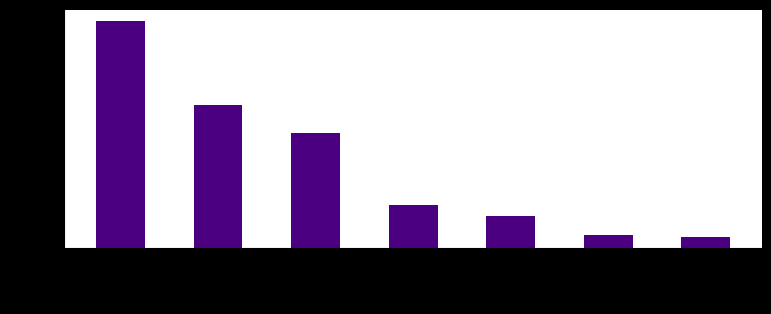

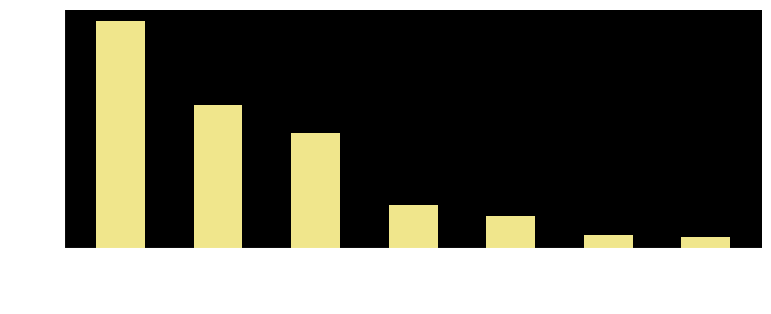

In [21]:
for background in ["default", "dark_background"]:
    fig = plt.figure(figsize=(9, 3.5))
    plt.style.use(background)
    ax = plt.subplot(1, 1, 1)

    times = 1000000 * np.asarray([
        t_naive.average,
        t_numpy.average,
        t_numpy_v2.average,
        t_cython.average,
        t_numba.average,
        t_cpp.average,
        t_pybind11.average,
    ])

    labels = [
        "Naive",
        "NumPy",
        "NumPy + \nstride trick",
        "Cython",
        "Numba",
        "C++ and \nnanobind",
        "C++ and \npybind11",
    ]

    for i in range(len(labels)):
        labels[i] = labels[i] + f"\n({times[i]:.1f} µs)"
    
    plt.bar(
        range(7),
        times,
        tick_label=labels,
        width=0.5,
        color="indigo" if (background == "default") else "khaki"
    )
    ax.spines[["top", "right"]].set_visible(False)
    plt.ylabel("Average time (µs)")
    plt.yscale("log")
    #plt.xticks(rotation=90)
    fig.subplots_adjust(bottom=0.2)
    plt.savefig(f"{background}.svg", dpi=300, transparent=True)
    plt.show()